In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# 1) Force working directory to repo root (so io.py relative paths behave)
repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
os.chdir(repo_root)

print("CWD:", Path.cwd())
print("Repo root contents:", [p.name for p in Path.cwd().iterdir()][:10])

CWD: C:\Users\kroep\Desktop\AI\ssl-for-ood-molecules
Repo root contents: ['.git', '.gitignore', '.ipynb_checkpoints', 'config', 'config.yaml', 'data', 'notebooks', 'notes.txt', 'pipeline.ipynb', 'pyproject.toml']


#### Generate dataset-splits

In [3]:
# Import loaders (works if you've run: pip install -e .)
from ssl_for_ood.data.io import load_all_data, load_gfp_data, load_aav_data, load_tfbind8_data

out = load_all_data()

for name, (train_df, val_ood_df, test_df, out_dir) in out.items():
    p = Path(out_dir).resolve()
    print(name, "out_dir:", p)
    print("exists:", p.exists())
    if p.exists():
        print("files:", sorted([x.name for x in p.iterdir()]))

gfp out_dir: C:\Users\kroep\Desktop\AI\ssl-for-ood-molecules\data\gfp\splits
exists: True
files: ['metadata.txt', 'target_unlabeled.csv', 'test.csv', 'train.csv', 'val_id.csv', 'val_ood.csv']
aav out_dir: C:\Users\kroep\Desktop\AI\ssl-for-ood-molecules\data\aav\splits
exists: True
files: ['.ipynb_checkpoints', 'metadata.txt', 'target_unlabeled.csv', 'test.csv', 'train.csv', 'val.csv', 'val_id.csv', 'val_ood.csv']
tfbind8 out_dir: C:\Users\kroep\Desktop\AI\ssl-for-ood-molecules\data\tfbind8\splits
exists: True
files: ['metadata.txt', 'target_unlabeled.csv', 'test.csv', 'train.csv', 'val_id.csv', 'val_ood.csv']


In [4]:
import pandas as pd

out = load_all_data()

for name, (train_df, val_ood_df, test_df, out_dir) in out.items():
    p = Path(out_dir).resolve()
    print(f"\n{name} out_dir: {p}")
    print("exists:", p.exists())

    # sizes of returned dataframes
    print("sizes (returned):",
          "train =", len(train_df),
          "| val_ood =", len(val_ood_df),
          "| test =", len(test_df))

    if p.exists():
        files = sorted([x.name for x in p.iterdir()])
        print("files:", files)

        # also load sizes of the extra splits saved to disk
        val_id_path = p / "val_id.csv"
        target_path = p / "target_unlabeled.csv"

        if val_id_path.exists():
            print("size (csv): val_id =", sum(1 for _ in open(val_id_path, "r", encoding="utf-8")) - 1)

        if target_path.exists():
            print("size (csv): target_unlabeled =", sum(1 for _ in open(target_path, "r", encoding="utf-8")) - 1)


gfp out_dir: C:\Users\kroep\Desktop\AI\ssl-for-ood-molecules\data\gfp\splits
exists: True
sizes (returned): train = 28751 | val_ood = 5000 | test = 8151
files: ['metadata.txt', 'target_unlabeled.csv', 'test.csv', 'train.csv', 'val_id.csv', 'val_ood.csv']
size (csv): val_id = 3194
size (csv): target_unlabeled = 8951

aav out_dir: C:\Users\kroep\Desktop\AI\ssl-for-ood-molecules\data\aav\splits
exists: True
sizes (returned): train = 50360 | val_ood = 5000 | test = 7853
files: ['.ipynb_checkpoints', 'metadata.txt', 'target_unlabeled.csv', 'test.csv', 'train.csv', 'val.csv', 'val_id.csv', 'val_ood.csv']
size (csv): val_id = 5596
size (csv): target_unlabeled = 7076

tfbind8 out_dir: C:\Users\kroep\Desktop\AI\ssl-for-ood-molecules\data\tfbind8\splits
exists: True
sizes (returned): train = 19039 | val_ood = 5000 | test = 24165
files: ['metadata.txt', 'target_unlabeled.csv', 'test.csv', 'train.csv', 'val_id.csv', 'val_ood.csv']
size (csv): val_id = 2115
size (csv): target_unlabeled = 15472


### Data Analysis

In [5]:
import torch
if torch.cuda.is_available():
    print(f'Using GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU found')

Using GPU: NVIDIA GeForce GTX 1660 SUPER


In [6]:
df_gfp_train = pd.read_csv(os.path.join('data', 'gfp', 'splits', 'train.csv'))
df_aav_train = pd.read_csv(os.path.join('data', 'aav', 'splits', 'train.csv'))
df_tfbind8_train = pd.read_csv(os.path.join('data', 'tfbind8', 'splits', 'train.csv'))

In [8]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# -----------------------------
# Utilities
# -----------------------------
def ensure_dir(path: str | Path) -> Path:
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def save_figure(fig: plt.Figure, out_path: Path, dpi: int = 200) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)


def dataset_outdir(dataset_name: str, root: str = "results/data_exploration") -> Path:
    # normalize dataset name for file paths
    safe_name = dataset_name.strip().lower().replace(" ", "_")
    return ensure_dir(Path(root) / safe_name)


# -----------------------------
# 1) Y-value / label plots
# -----------------------------
def plot_label_distribution(
    df: pd.DataFrame,
    dataset_name: str,
    *,
    bins: int = 50,
    root: str = "results/data_exploration",
) -> None:
    """
    Plots the overall label distribution for a dataset and saves it.
    """
    outdir = dataset_outdir(dataset_name, root=root)

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.hist(df["label"].values, bins=bins, edgecolor="black", color="#4C72B0", alpha=0.9)

    ax.set_xlabel("Label (y)")
    ax.set_ylabel("Number of sequences")
    ax.set_title(f"{dataset_name}: label distribution")

    fig.tight_layout()
    save_figure(fig, outdir / "label_distribution.png")


def plot_label_distribution_by_split(
    df: pd.DataFrame,
    dataset_name: str,
    *,
    bins: int = 50,
    root: str = "results/data_exploration",
) -> None:
    """
    Plots label distributions per split (train/val/test) for sanity checking.
    """
    outdir = dataset_outdir(dataset_name, root=root)

    # If split isn't present or only one split exists, skip gracefully.
    if "split" not in df.columns or df["split"].nunique() <= 1:
        return

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    for split_name, sub in df.groupby("split"):
        ax.hist(
            sub["label"].values,
            bins=bins,
            alpha=0.45,
            label=str(split_name),
            edgecolor="black",
            linewidth=0.5,
        )

    ax.set_xlabel("Label (y)")
    ax.set_ylabel("Number of sequences")
    ax.set_title(f"{dataset_name}: label distribution by split")
    ax.legend(title="Split")
    fig.tight_layout()
    save_figure(fig, outdir / "label_distribution_by_split.png")


# -----------------------------
# 2) Mutation distance analysis (new setup)
# -----------------------------
def plot_mutation_distance_histogram(
    df: pd.DataFrame,
    dataset_name: str,
    *,
    root: str = "results/data_exploration",
) -> None:
    """
    Plots the distribution of mut_dist (already provided).
    """
    outdir = dataset_outdir(dataset_name, root=root)

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    # mut_dist is often integer, but we handle general numeric
    ax.hist(df["mut_dist"].values, bins=range(int(df["mut_dist"].min()), int(df["mut_dist"].max()) + 2),
            edgecolor="black", color="#55A868", alpha=0.9)

    ax.set_xlabel("Mutation distance (mut_dist)")
    ax.set_ylabel("Number of sequences")
    ax.set_title(f"{dataset_name}: mutation distance distribution")

    fig.tight_layout()
    save_figure(fig, outdir / "mut_dist_hist.png")


def plot_label_by_mutation_distance_box(
    df: pd.DataFrame,
    dataset_name: str,
    *,
    root: str = "results/data_exploration",
) -> None:
    """
    Boxplot of label by mutation distance.
    This is the simplest 'effect of mutations' analysis given mut_dist.
    """
    outdir = dataset_outdir(dataset_name, root=root)

    # Make mut_dist categorical for stable ordering on x-axis
    work = df.copy()
    work["mut_dist"] = work["mut_dist"].astype(int)

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    sns.boxplot(
        data=work,
        x="mut_dist",
        y="label",
        color="lightgray",
        ax=ax,
        fliersize=2,
        linewidth=1,
    )
    ax.set_xlabel("Mutation distance (number of mutations)")
    ax.set_ylabel("Label (y)")
    ax.set_title(f"{dataset_name}: label distribution by mutation distance")

    fig.tight_layout()
    save_figure(fig, outdir / "label_by_mut_dist_box.png")


def plot_label_by_mutation_distance_mean_ci(
    df: pd.DataFrame,
    dataset_name: str,
    *,
    root: str = "results/data_exploration",
) -> None:
    """
    Mean label with confidence intervals by mutation distance.
    Often easier to interpret than boxplots in a thesis.
    """
    outdir = dataset_outdir(dataset_name, root=root)

    work = df.copy()
    work["mut_dist"] = work["mut_dist"].astype(int)

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    sns.pointplot(
        data=work,
        x="mut_dist",
        y="label",
        errorbar=("ci", 95),
        ax=ax,
        color="#4C72B0",
    )
    ax.set_xlabel("Mutation distance (number of mutations)")
    ax.set_ylabel("Mean label (y)")
    ax.set_title(f"{dataset_name}: mean label by mutation distance (95% CI)")

    fig.tight_layout()
    save_figure(fig, outdir / "label_by_mut_dist_mean_ci.png")


# -----------------------------
# 3) Stronger ruggedness proxy:
#    |Δy| as function of Δmut_dist between pairs
# -----------------------------
def plot_delta_label_by_delta_mut_dist(
    df: pd.DataFrame,
    dataset_name: str,
    *,
    n_pairs: int = 50_000,
    seed: int = 42,
    root: str = "results/data_exploration",
) -> None:
    """
    Samples random pairs of sequences and measures:
      delta_mut_dist = |mut_dist_i - mut_dist_j|
      delta_label    = |label_i - label_j|
    Then plots delta_label grouped by delta_mut_dist.

    This is NOT the same as true Hamming distance between sequences,
    but it is a useful 'global ruggedness' proxy given the provided mut_dist.
    """
    outdir = dataset_outdir(dataset_name, root=root)

    rng = np.random.default_rng(seed)
    n = len(df)
    if n < 2:
        return

    idx1 = rng.integers(0, n, size=n_pairs)
    idx2 = rng.integers(0, n, size=n_pairs)

    mut1 = df["mut_dist"].to_numpy()
    mut2 = mut1  # same array
    y = df["label"].to_numpy()

    delta_mut = np.abs(mut1[idx1] - mut2[idx2]).astype(int)
    delta_y = np.abs(y[idx1] - y[idx2])

    pairs = pd.DataFrame({"delta_mut_dist": delta_mut, "abs_delta_label": delta_y})

    # Avoid huge x-axis if mut_dist range is large: keep only reasonable deltas
    # (you can remove this if you want everything)
    max_delta_to_plot = int(np.percentile(pairs["delta_mut_dist"], 99))
    pairs = pairs[pairs["delta_mut_dist"] <= max_delta_to_plot]

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    sns.boxplot(
        data=pairs,
        x="delta_mut_dist",
        y="abs_delta_label",
        color="lightgray",
        ax=ax,
        fliersize=1.5,
        linewidth=1,
    )
    ax.set_xlabel(r"$|\Delta$ mutation distance$|$")
    ax.set_ylabel(r"$|\Delta y|$")
    ax.set_title(f"{dataset_name}: absolute label change vs. change in mutation distance")

    fig.tight_layout()
    save_figure(fig, outdir / "delta_label_by_delta_mut_dist_box.png")


# -----------------------------
# Runner: apply to all datasets
# -----------------------------
def run_data_exploration(
    datasets: dict[str, pd.DataFrame],
    *,
    root: str = "results/data_exploration",
) -> None:
    for dataset_name, df in datasets.items():
        # Label plots
        plot_label_distribution(df, dataset_name, root=root)
        plot_label_distribution_by_split(df, dataset_name, root=root)

        # Mutation distance plots (given mut_dist exists)
        if "mut_dist" in df.columns:
            plot_mutation_distance_histogram(df, dataset_name, root=root)
            plot_label_by_mutation_distance_box(df, dataset_name, root=root)
            plot_label_by_mutation_distance_mean_ci(df, dataset_name, root=root)
            plot_delta_label_by_delta_mut_dist(df, dataset_name, root=root)


# Example usage:
datasets = {
    "GFP": df_gfp_train,
    "AAV": df_aav_train,
    "TFBind8": df_tfbind8_train,
}

run_data_exploration(datasets)

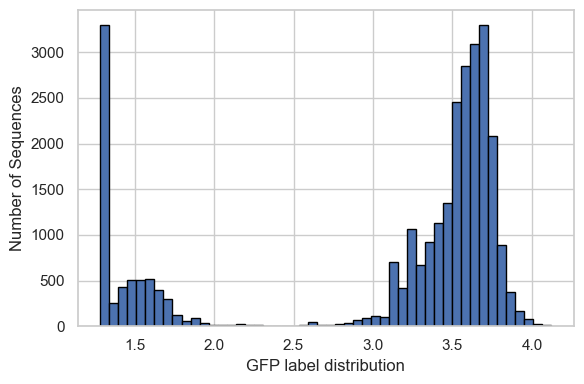

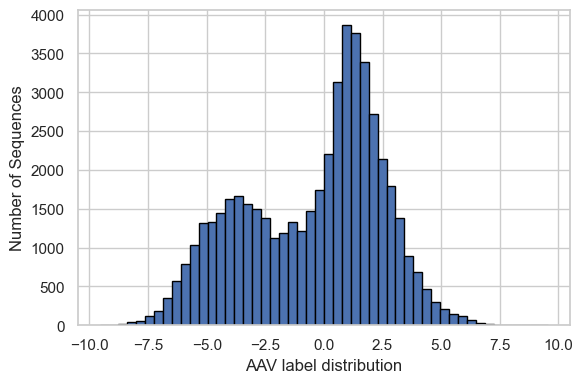

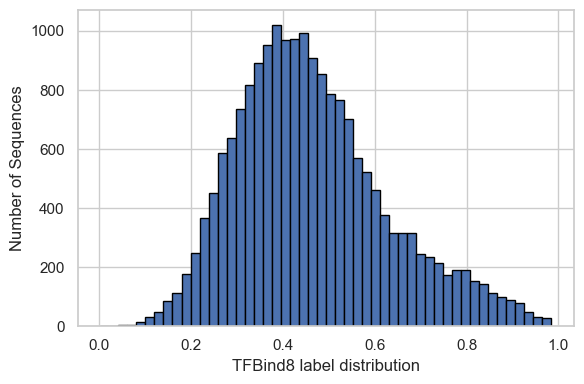

In [9]:
def plot_dataset_labels(df, title):
    # Plot the histogram of y values
    plt.figure(figsize=(6, 4))
    plt.hist(df.label, bins=50, edgecolor='black')
    plt.xlabel(title)
    plt.ylabel("Number of Sequences")
    #plt.title("Distribution of Binding Scores (dataset.y)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_all_y_values(input_list):
    for df, title in input_list:
        plot_dataset_labels(df, title)

plot_all_y_values(
    [(df_gfp_train, 'GFP label distribution'),
     (df_aav_train, 'AAV label distribution'),
     (df_tfbind8_train, 'TFBind8 label distribution')]
)

### Load and Preprocess

In [10]:
import torch
print(torch.version.cuda)
print(torch.backends.cudnn.version())
print(torch.__version__)

12.1
90100
2.5.1+cu121


In [11]:
import torch
if torch.cuda.is_available():
    print(f'Using GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU found')

Using GPU: NVIDIA GeForce GTX 1660 SUPER


In [12]:
import pandas as pd
import numpy as np

In [20]:
def load_data(dataset: str, split: str):
    return pd.read_csv(os.path.join('data', dataset, 'splits', f'{split}.csv'))

In [25]:
df_aav_train = load_data(dataset='aav', split='train')
df_gfp_train = load_data(dataset='gfp', split='train')
df_tfbind8_train = load_data(dataset='tfbind8', split='train')

In [34]:
load_data(dataset='aav', split='train')

,sequence,label,mut_dist,split
0,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,1.973905,5,train
1,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-1.542606,5,train
2,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,2.315324,5,train
3,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,0.783575,5,train
4,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,1.964286,5,train
...,...,...,...,...
50355,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-2.190229,5,train
50356,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-1.375420,3,train
50357,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-2.287051,4,train
50358,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-5.604717,4,train
